In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("drive/MyDrive/project_dataset_housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
y = df_encoded['price']
X = df_encoded.drop('price', axis = 1)
X = sm.add_constant(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42)

In [6]:
OLS_model = sm.OLS(y_train, X_train).fit()
OLS_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     70.90
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.16e-97
Time:                        00:23:43   Log-Likelihood:                -6635.2
No. Observations:                 436   AIC:                         1.330e+04
Df Residuals:                     422   BIC:                         1.336e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              2.6e+05   2.74e+05      0.949      0.343   -2.79e+05    7.99e+05
area                              235.9688     24.903      9.476      0.000     187.020     284.918
bedrooms                         7.678e+04   7.54e+04      1.018      0.309   -7.14e+04    2.25e+05
bathrooms                        1.094e+06   1.14e+05      9.564      0.000     8.7e+05    1.32e+06
stories                          4.075e+05   6.88e+04      5.919      0.000    2.72e+05    5.43e+05
parking                          2.248e+05   6.18e+04      3.639      0.000    1.03e+05    3.46e+05
mainroad_yes                     3.679e+05   1.49e+05      2.464      0.014    7.44e+04    6.61e+05
guestroom_yes                    2.316e+05   1.41e+05      1.648      0.100   -4.47e+04    5.08e+05
basement_yes                     3.903e+05   1.18e+05      3.320      0.001    1.59e+05    6.21e+05
hotwaterheating_yes              6.846e+05   2.23e+05      3.070      0.002    2.46e+05    1.12e+06
airconditioning_yes              7.914e+05   1.17e+05      6.772      0.000    5.62e+05    1.02e+06
prefarea_yes                     6.299e+05   1.21e+05      5.205      0.000    3.92e+05    8.68e+05
furnishingstatus_semi-furnished -1.269e+05   1.22e+05     -1.041      0.299   -3.66e+05    1.13e+05
furnishingstatus_unfurnished    -4.136e+05   1.34e+05     -3.077      0.002   -6.78e+05   -1.49e+05
==============================================================================
Omnibus:                       74.015   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              191.938
Skew:                           0.833   Prob(JB):                     2.10e-42
Kurtosis:                       5.791   Cond. No.                     3.48e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.48e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [11]:
y_pred = OLS_model.predict(X_test)
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2_test = 1 - ss_res / ss_tot

print(f"R-squared: {r2_test}")
print(f"Mean Squared Error: {mean_squared_error(y_pred, y_test)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_pred, y_test))}")

R-squared: 0.652924264215317
Mean Squared Error: 1754318687330.6711
Root Mean Squared Error: 1324506.9600914414


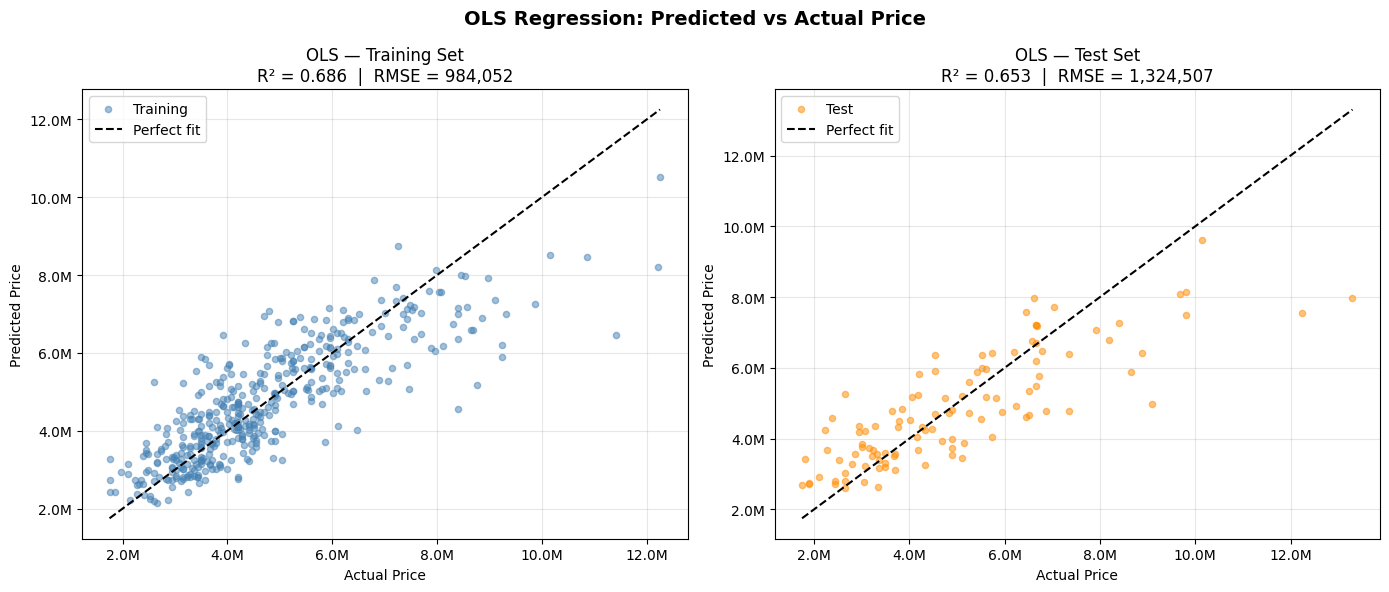

In [12]:

# OLS: Predicted vs Actual for train and test sets
y_pred_train = OLS_model.predict(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_pred, label, color in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred],
    ['Training', 'Test'],
    ['steelblue', 'darkorange'],
):
    ax.scatter(y_true, y_pred, alpha=0.5, s=20, color=color, label=label)
    # Perfect-prediction reference line
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f'OLS — {label} Set\nR² = {1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2):.3f}  |  RMSE = {np.sqrt(mean_squared_error(y_true, y_pred)):,.0f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    # Format axes in millions for readability
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('OLS Regression: Predicted vs Actual Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### OLS Model 

y-hat = 2.6e+05	+ 235.9688(area) + 7.678e+04(bedrooms) + 1.094e+06(bathrooms) + 4.075e+05(stories) + 2.248e+05(parking) + 3.679e+05(mainroad_yes) + 2.316e+05(guestroom_yes) 
    + 3.903e+05(basement_yes) + 6.846e+05(hotwaterheating_yes) + 7.914e+05(airconditioning_yes) + 6.299e+05(prefarea_yes) - 1.269e+05(furnishingstatus_semi-furnished)
    - 4.136e+05(furnishingstatus_unfurnished) 

**Test MSE** = 1,754,318,687,330

Optimal lambda (α): 1.0000e+04


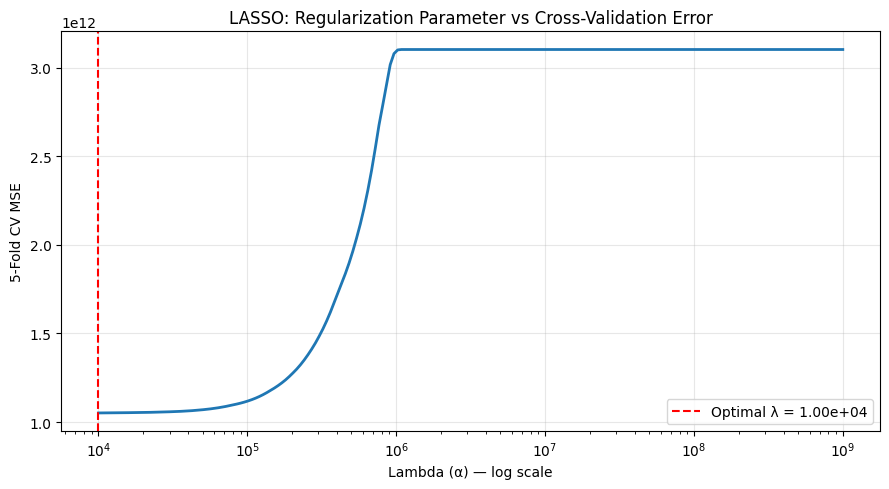


LASSO Coefficients (on standardized features):
  intercept : 4706527.39
  area                                         : 517428.7922
  bedrooms                                     : 54260.4114
  bathrooms                                    : 519105.4279
  stories                                      : 344636.0998
  parking                                      : 188927.5654
  mainroad_yes                                 : 124881.3988
  guestroom_yes                                : 85024.3319
  basement_yes                                 : 181523.7263
  hotwaterheating_yes                          : 139644.5577
  airconditioning_yes                          : 362612.2593
  prefarea_yes                                 : 261253.9734
  furnishingstatus_semi-furnished              : -41419.5991
  furnishingstatus_unfurnished                 : -174168.7997

Test R-squared : 0.650170
Test MSE       : 1768239121769.2795
Test RMSE      : 1329751.5263


In [9]:
## LASSO Model

# Drop the constant column — sklearn's Lasso handles the intercept internally
X_train_lasso = X_train.drop('const', axis=1)
X_test_lasso  = X_test.drop('const', axis=1)

# Standardize features (regularization is scale-sensitive)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lasso)
X_test_scaled  = scaler.transform(X_test_lasso)

# --- Cross-validation to select optimal lambda ---
alphas = np.logspace(4, 9, 200)   # lambda candidates: 1e4 … 1e9
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_errors = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=20000)
    mse_cv = -cross_val_score(lasso, X_train_scaled, y_train,
                              cv=kf, scoring='neg_mean_squared_error')
    cv_errors.append(np.mean(mse_cv))

optimal_alpha = alphas[np.argmin(cv_errors)]
print(f"Optimal lambda (α): {optimal_alpha:.4e}")

# --- Plot lambda vs CV error ---
plt.figure(figsize=(9, 5))
plt.semilogx(alphas, cv_errors, linewidth=2)
plt.axvline(optimal_alpha, color='red', linestyle='--',
            label=f'Optimal λ = {optimal_alpha:.2e}')
plt.xlabel('Lambda (α) — log scale')
plt.ylabel('5-Fold CV MSE')
plt.title('LASSO: Regularization Parameter vs Cross-Validation Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Fit LASSO with optimal lambda ---
lasso_model = Lasso(alpha=optimal_alpha, max_iter=20000)
lasso_model.fit(X_train_scaled, y_train)

feature_names = X_train_lasso.columns.tolist()
intercept     = lasso_model.intercept_
coefs         = lasso_model.coef_

print("\nLASSO Coefficients (on standardized features):")
print(f"  intercept : {intercept:.2f}")
for name, coef in zip(feature_names, coefs):
    print(f"  {name:45s}: {coef:.4f}")

# --- Evaluate on test set ---
y_pred_lasso = lasso_model.predict(X_test_scaled)
ss_res = np.sum((y_test - y_pred_lasso) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2_lasso  = 1 - ss_res / ss_tot
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print(f"\nTest R-squared : {r2_lasso:.6f}")
print(f"Test MSE       : {mse_lasso:.4f}")
print(f"Test RMSE      : {np.sqrt(mse_lasso):.4f}")

### LASSO Model

**Optimal regularization parameter:** λ = 1.0000e+04

ŷ = 4706527.39 + (517428.7922)·area_std + (54260.4114)·bedrooms_std + (519105.4279)·bathrooms_std + (344636.0998)·stories_std + (188927.5654)·parking_std + (124881.3988)·mainroad_yes_std + (85024.3319)·guestroom_yes_std + (181523.7263)·basement_yes_std + (139644.5577)·hotwaterheating_yes_std + (362612.2593)·airconditioning_yes_std + (261253.9734)·prefarea_yes_std + (-41419.5991)·furnishingstatus_semi-furnished_std + (-174168.7997)·furnishingstatus_unfurnished_std


**Test MSE** = 1,768,239,121,769

Optimal bandwidth h: 386.5880


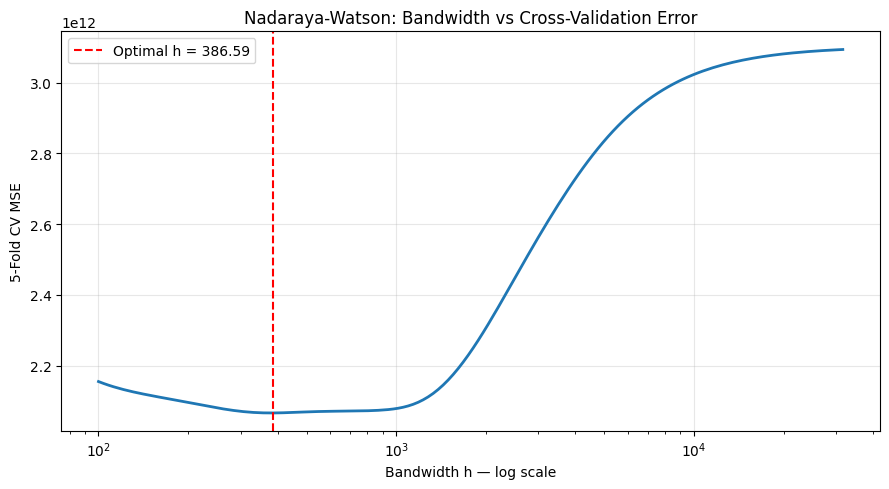


Test R-squared : 0.247462
Test MSE       : 3803754026232.9570
Test RMSE      : 1950321.5187


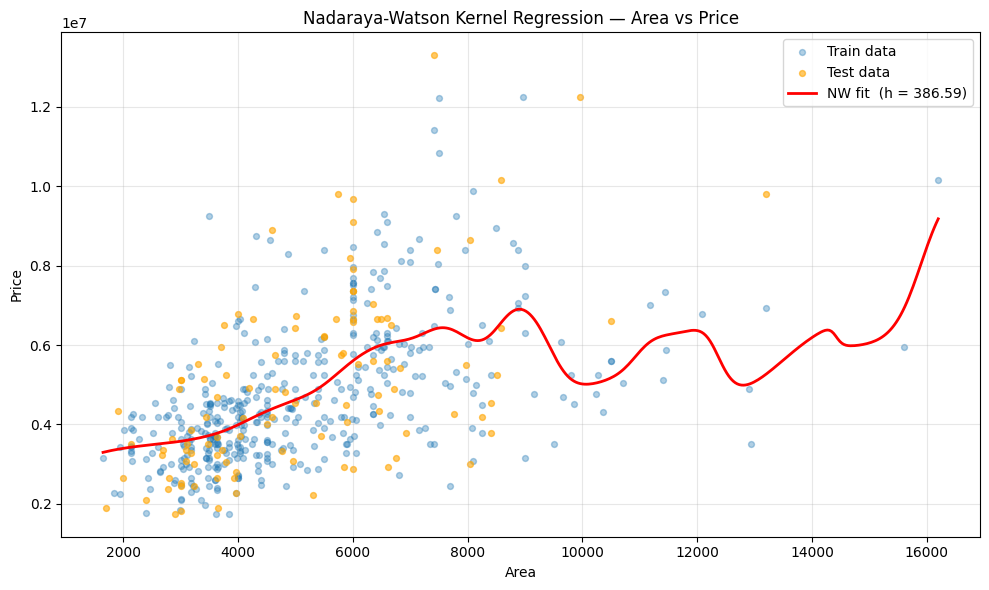

In [10]:
## Nadaraya-Watson Kernel Regression (feature: area)

# Single continuous feature with strongest signal
feature = 'area'

x_train_nw = X_train[feature].values.astype(float)
x_test_nw  = X_test[feature].values.astype(float)
y_train_nw = y_train.values.astype(float)
y_test_nw  = y_test.values.astype(float)

# Gaussian kernel (normalization constant cancels in the ratio)
def gaussian_kernel(u):
    return np.exp(-0.5 * u ** 2)

def nw_predict(x_train, y_train, x_query, h):
    preds = np.empty(len(x_query))
    for i, x in enumerate(x_query):
        w = gaussian_kernel((x - x_train) / h)
        w_sum = w.sum()
        preds[i] = np.dot(w, y_train) / w_sum if w_sum > 0 else y_train.mean()
    return preds

# --- Cross-validation to select optimal bandwidth h ---
bandwidths   = np.logspace(2, 4.5, 150)          # h from ~100 to ~31 000 (area units)
kf           = KFold(n_splits=5, shuffle=True, random_state=42)
cv_errors_nw = []

for h in bandwidths:
    fold_mses = []
    for train_idx, val_idx in kf.split(x_train_nw):
        y_val_pred = nw_predict(x_train_nw[train_idx], y_train_nw[train_idx],
                                x_train_nw[val_idx], h)
        fold_mses.append(mean_squared_error(y_train_nw[val_idx], y_val_pred))
    cv_errors_nw.append(np.mean(fold_mses))

optimal_h = bandwidths[np.argmin(cv_errors_nw)]
print(f"Optimal bandwidth h: {optimal_h:.4f}")

# --- Plot h vs CV error ---
plt.figure(figsize=(9, 5))
plt.semilogx(bandwidths, cv_errors_nw, linewidth=2)
plt.axvline(optimal_h, color='red', linestyle='--',
            label=f'Optimal h = {optimal_h:.2f}')
plt.xlabel('Bandwidth h — log scale')
plt.ylabel('5-Fold CV MSE')
plt.title('Nadaraya-Watson: Bandwidth vs Cross-Validation Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Evaluate on test set ---
y_pred_nw = nw_predict(x_train_nw, y_train_nw, x_test_nw, optimal_h)
mse_nw = mean_squared_error(y_test_nw, y_pred_nw)
ss_res = np.sum((y_test_nw - y_pred_nw) ** 2)
ss_tot = np.sum((y_test_nw - y_test_nw.mean()) ** 2)
r2_nw  = 1 - ss_res / ss_tot

print(f"\nTest R-squared : {r2_nw:.6f}")
print(f"Test MSE       : {mse_nw:.4f}")
print(f"Test RMSE      : {np.sqrt(mse_nw):.4f}")

# --- Visualize the fitted curve ---
x_plot    = np.linspace(x_train_nw.min(), x_train_nw.max(), 400)
y_plot    = nw_predict(x_train_nw, y_train_nw, x_plot, optimal_h)

plt.figure(figsize=(10, 6))
plt.scatter(x_train_nw, y_train_nw, alpha=0.35, s=18, label='Train data')
plt.scatter(x_test_nw,  y_test_nw,  alpha=0.6,  s=18, color='orange', label='Test data')
plt.plot(x_plot, y_plot, color='red', linewidth=2,
         label=f'NW fit  (h = {optimal_h:.2f})')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Nadaraya-Watson Kernel Regression — Area vs Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Nadaraya-Watson Kernel Regression Model

**Selected feature:** area  
**Kernel:** Gaussian — $K(u) = \exp\!\left(-\tfrac{u^2}{2}\right)$  
**Optimal bandwidth:** $h =$ *386.5880*

**Model formula:**

$$\hat{y}(x^*) = \frac{\displaystyle\sum_{i=1}^{n} K\!\left(\frac{x^* - x_i}{h}\right) y_i}{\displaystyle\sum_{i=1}^{n} K\!\left(\frac{x^* - x_i}{h}\right)}$$

where $x^*$ is the area of the house being predicted, $x_i$ and $y_i$ are the training areas and prices, and $K(u) = e^{-u^2/2}$ is the Gaussian kernel.

**Test MSE** = *3,803,754,026,232*